# XGBoost Training Notebook

This notebook follows the same workflow as the training script.
The only model-specific difference is the classifier.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from xgboost import XGBClassifier

ROOT_DIR = Path.cwd().resolve().parent.parent
PYTHON_DIR = ROOT_DIR / "python"
if str(PYTHON_DIR) not in sys.path:
    sys.path.append(str(PYTHON_DIR))

from common import (  # noqa: E402
    CLASS_ORDER,
    coerce_feature_types,
    evaluate_predictions,
    load_tabular_file,
    build_preprocessor,
    split_feature_columns,
    infer_numeric_like_columns,
    standardize_columns,
    find_column,
    clean_rating_label,
    create_rating_group,
    IDENTIFIER_ALIASES,
    TARGET_ALIASES,
)

# Auto-detect the first CSV or Excel file in the data/ directory.
_data_dir = ROOT_DIR / "data"
_candidates = sorted(
    list(_data_dir.glob("*.csv")) + list(_data_dir.glob("*.xlsx")) + list(_data_dir.glob("*.xls"))
)
if not _candidates:
    raise FileNotFoundError(
        f"No CSV or Excel file found in {_data_dir}. ",
        "Please place your dataset there and re-run this cell.",
    )
DATA_PATH = _candidates[0]
print(f"Using dataset: {DATA_PATH}")
print("Imports ready")

Using dataset: C:\Users\24042662\Desktop\C300\CreditSight\data\set A corporate_rating.csv
Imports ready


In [2]:
# Step 1: Load the dataset.
raw_df = load_tabular_file(str(DATA_PATH))
df = standardize_columns(raw_df)
print(df.shape)
df.head()

(2029, 31)


,Rating,Name,Symbol,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,...,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
0,A,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,11/27/2015,Consumer Durables,0.945894,0.426395,0.099690,44.203245,...,0.202716,0.437551,6.810673,9.809403,4.008012,0.049351,7.057088,15.565438,0.058638,3.906655
1,BBB,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2/13/2014,Consumer Durables,1.033559,0.498234,0.203120,38.991156,...,0.074155,0.541997,8.625473,17.402270,3.156783,0.048857,6.460618,15.914250,0.067239,4.002846
2,BBB,Whirlpool Corporation,WHR,Fitch Ratings,3/6/2015,Consumer Durables,0.963703,0.451505,0.122099,50.841385,...,0.214529,0.513185,9.693487,13.103448,4.094575,0.044334,10.491970,18.888889,0.074426,3.483510
3,BBB,Whirlpool Corporation,WHR,Fitch Ratings,6/15/2012,Consumer Durables,1.019851,0.510402,0.176116,41.161738,...,1.816667,-0.147170,-1.015625,14.440104,3.630950,-0.012858,4.080741,6.901042,0.028394,4.581150
4,BBB,Whirlpool Corporation,WHR,Standard & Poor's Ratings Services,10/24/2016,Consumer Durables,0.957844,0.495432,0.141608,47.761126,...,0.166966,0.451372,7.135348,14.257556,4.012780,0.053770,8.293505,15.808147,0.058065,3.857790


In [3]:
# Step 2: Check missing values and duplicates.
missing_values = df.isna().sum().sort_values(ascending=False)
duplicate_rows = int(df.duplicated().sum())
print(missing_values[missing_values > 0])
print("Duplicate rows:", duplicate_rows)

Series([], dtype: int64)
Duplicate rows: 0


In [4]:
# Step 3: Create the RatingGroup target.
rating_column = find_column(df, TARGET_ALIASES)
if rating_column is None:
    raise ValueError("No rating column found in the dataset.")

working_df = df.copy()
working_df[rating_column] = working_df[rating_column].apply(clean_rating_label)
working_df["RatingGroup"] = working_df[rating_column].apply(create_rating_group)
working_df = working_df.dropna(subset=["RatingGroup"]).copy()

identifier_columns = []
for alias in IDENTIFIER_ALIASES:
    found = find_column(working_df, [alias])
    if found and found not in identifier_columns:
        identifier_columns.append(found)

if rating_column not in identifier_columns:
    identifier_columns.append(rating_column)

working_df = working_df.drop(columns=identifier_columns, errors="ignore")
working_df = infer_numeric_like_columns(working_df, exclude_columns=["RatingGroup"])
print(working_df["RatingGroup"].value_counts())

RatingGroup
Speculative        792
Investment-Low     671
Investment-High    494
Distressed          72
Name: count, dtype: int64


In [5]:
# Step 4: Select features and prepare the training data.
feature_columns = [column for column in working_df.columns if column != "RatingGroup"]
numeric_columns, categorical_columns = split_feature_columns(working_df, "RatingGroup", [])
X = working_df[feature_columns].copy()
X = coerce_feature_types(X, numeric_columns, categorical_columns)
y = working_df["RatingGroup"].copy()
print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

Numeric columns: ['currentRatio', 'quickRatio', 'cashRatio', 'daysOfSalesOutstanding', 'netProfitMargin', 'pretaxProfitMargin', 'grossProfitMargin', 'operatingProfitMargin', 'returnOnAssets', 'returnOnCapitalEmployed', 'returnOnEquity', 'assetTurnover', 'fixedAssetTurnover', 'debtEquityRatio', 'debtRatio', 'effectiveTaxRate', 'freeCashFlowOperatingCashFlowRatio', 'freeCashFlowPerShare', 'cashPerShare', 'companyEquityMultiplier', 'ebitPerRevenue', 'enterpriseValueMultiple', 'operatingCashFlowPerShare', 'operatingCashFlowSalesRatio', 'payablesTurnover']
Categorical columns: ['Sector']


In [6]:
# Step 5: Split the dataset and train the model.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded,
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(numeric_columns, categorical_columns)),
        ("model", XGBClassifier(random_state=42, eval_metric="mlogloss")),
    ]
)
pipeline.fit(X_train, y_train)
print("Model trained")

Model trained


In [7]:
# Step 6: Evaluate the trained model.
y_pred = pipeline.predict(X_test)
y_test_labels = label_encoder.inverse_transform(y_test)
y_pred_labels = label_encoder.inverse_transform(y_pred.astype(int))
metrics = evaluate_predictions(y_test_labels, y_pred_labels, CLASS_ORDER)
print(metrics["accuracy"])
print(metrics["classification_report_text"])


0.6666666666666666
                 precision    recall  f1-score   support

Investment-High       0.64      0.62      0.63       148
 Investment-Low       0.63      0.57      0.60       201
    Speculative       0.70      0.82      0.76       238
     Distressed       0.80      0.18      0.30        22

       accuracy                           0.67       609
      macro avg       0.69      0.55      0.57       609
   weighted avg       0.67      0.67      0.66       609



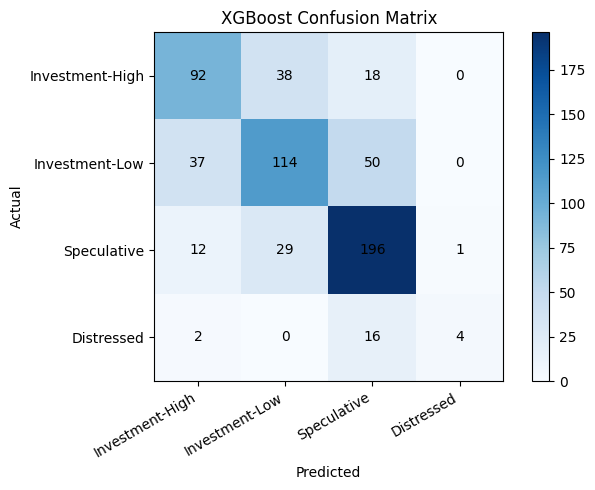

In [8]:
# Step 7: Show the confusion matrix.
cm = np.array(metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASS_ORDER)))
ax.set_yticks(range(len(CLASS_ORDER)))
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha="right")
ax.set_yticklabels(CLASS_ORDER)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("XGBoost Confusion Matrix")

for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        ax.text(
            column_index,
            row_index,
            cm[row_index, column_index],
            ha="center",
            va="center",
            color="black",
        )

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## XGBoost Ablation Study

Every section below starts from the same untouched `X_train`, `X_test`, `y_train`, `y_test`,
and preprocessing definition (`build_preprocessor`) created in Step 5 above - none of them
are refit or modified. Each section changes exactly one variable relative to the baseline
`XGBClassifier(random_state=42, eval_metric="mlogloss")` trained in Step 5/6, so results can
be attributed to that single change. Running totals are kept in `ablation_records`, and the
final section consolidates everything into one comparison table. This section does not
touch `pipeline`, `metrics`, or any other variable the Min-Max Normalization / Experiment 7 /
Experiment 8 / SHAP sections below rely on.


In [9]:
# Section 1: Baseline
import time

from sklearn.base import clone
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import f1_score


def per_class_f1(y_true_labels, y_pred_labels, class_order):
    scores = f1_score(y_true_labels, y_pred_labels, labels=class_order, average=None, zero_division=0)
    return {label: float(score) for label, score in zip(class_order, scores)}


def make_ablation_row(step_name, metrics_dict, y_true_labels, y_pred_labels, notes=""):
    row = {
        "Step": step_name,
        "Accuracy": metrics_dict["accuracy"],
        "Macro F1": metrics_dict["macro_f1"],
        "Weighted F1": metrics_dict["weighted_f1"],
    }
    row.update(per_class_f1(y_true_labels, y_pred_labels, CLASS_ORDER))
    row["Notes"] = notes
    return row


# Baseline is exactly the model already trained in Step 5/6 above - XGBClassifier(random_state=42,
# eval_metric="mlogloss"), all other params default. Reused as-is (not refit); copied into new names
# so the Min-Max/Experiment cells below, which read "metrics" and "pipeline" directly, are unaffected.
ablation_baseline_metrics = metrics
ablation_baseline_pred_labels = y_pred_labels

ablation_records = []
ablation_results = {}

ablation_records.append(
    make_ablation_row(
        "1. Baseline",
        ablation_baseline_metrics,
        y_test_labels,
        ablation_baseline_pred_labels,
        notes="Fixed reference point for every later comparison. Untouched XGBClassifier defaults.",
    )
)
ablation_results["Baseline"] = ablation_baseline_metrics

pd.DataFrame(ablation_records)


,Step,Accuracy,Macro F1,Weighted F1,Investment-High,Investment-Low,Speculative,Distressed,Notes
0,1. Baseline,0.666667,0.570554,0.657103,0.632302,0.596859,0.756757,0.296296,Fixed reference point for every later comparis...


### 2. Hyperparameter tuning only

`RandomizedSearchCV` over `n_estimators`, `learning_rate`, `max_depth`, `subsample`,
`colsample_bytree`, `reg_alpha`, `reg_lambda`, `gamma`. No early stopping, no
`sample_weight`, no monotonic constraints. Searched on `X_train` only (5-fold CV inside
the search); scored once on the untouched `X_test`.

> **Note:** This search only exists to measure HPO's isolated contribution within the
> ablation study above - it uses a different search method and parameter space than the
> final tuning pass in **Experiment 7 / Experiment 8** later in the notebook. Its
> `best_params_` should not be read as the model's final chosen hyperparameters; those
> come from Experiment 7/8.


In [10]:
# Section 2: Hyperparameter tuning only
hpo_param_distributions = {
    "model__n_estimators": [100, 200, 300, 400, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__reg_alpha": [0, 0.01, 0.1, 1.0],
    "model__reg_lambda": [0.5, 1.0, 1.5, 2.0],
    "model__gamma": [0, 0.1, 0.3, 0.5],
}

ablation_hpo_search = RandomizedSearchCV(
    estimator=Pipeline(
        steps=[
            ("preprocessor", build_preprocessor(numeric_columns, categorical_columns)),
            ("model", XGBClassifier(random_state=42, eval_metric="mlogloss")),
        ]
    ),
    param_distributions=hpo_param_distributions,
    n_iter=40,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    refit=True,
)
ablation_hpo_search.fit(X_train, y_train)

hpo_pred = ablation_hpo_search.best_estimator_.predict(X_test)
hpo_pred_labels = label_encoder.inverse_transform(hpo_pred.astype(int))
hpo_metrics = evaluate_predictions(y_test_labels, hpo_pred_labels, CLASS_ORDER)

print("Best hyperparameters found:")
print(ablation_hpo_search.best_params_)
print(f"Best cross-validation accuracy: {ablation_hpo_search.best_score_:.4f}")

ablation_records.append(
    make_ablation_row(
        "2. Hyperparameter tuning only",
        hpo_metrics,
        y_test_labels,
        hpo_pred_labels,
        notes=f"RandomizedSearchCV (n_iter=40, cv=5) best params: {ablation_hpo_search.best_params_}",
    )
)
ablation_results["Hyperparameter tuning only"] = hpo_metrics

pd.DataFrame(ablation_records)


Best hyperparameters found:
{'model__subsample': 0.6, 'model__reg_lambda': 2.0, 'model__reg_alpha': 0, 'model__n_estimators': 400, 'model__max_depth': 8, 'model__learning_rate': 0.03, 'model__gamma': 0, 'model__colsample_bytree': 0.9}
Best cross-validation accuracy: 0.6549


,Step,Accuracy,Macro F1,Weighted F1,Investment-High,Investment-Low,Speculative,Distressed,Notes
0,1. Baseline,0.666667,0.570554,0.657103,0.632302,0.596859,0.756757,0.296296,Fixed reference point for every later comparis...
1,2. Hyperparameter tuning only,0.684729,0.553175,0.672391,0.680135,0.613333,0.765385,0.153846,"RandomizedSearchCV (n_iter=40, cv=5) best para..."


### 3. Class imbalance handling only

Baseline hyperparameters, unchanged, plus `sample_weight=compute_sample_weight("balanced",
y_train)` passed into `fit`. Nothing else changes from the baseline.


In [11]:
# Section 3: Class imbalance handling only
imbalance_pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(numeric_columns, categorical_columns)),
        ("model", XGBClassifier(random_state=42, eval_metric="mlogloss")),
    ]
)
imbalance_sample_weight = compute_sample_weight("balanced", y_train)
imbalance_pipeline.fit(X_train, y_train, model__sample_weight=imbalance_sample_weight)

imbalance_pred = imbalance_pipeline.predict(X_test)
imbalance_pred_labels = label_encoder.inverse_transform(imbalance_pred.astype(int))
imbalance_metrics = evaluate_predictions(y_test_labels, imbalance_pred_labels, CLASS_ORDER)

ablation_records.append(
    make_ablation_row(
        "3. Class imbalance handling only",
        imbalance_metrics,
        y_test_labels,
        imbalance_pred_labels,
        notes="Baseline hyperparameters + sample_weight=compute_sample_weight('balanced', y_train).",
    )
)
ablation_results["Class imbalance handling only"] = imbalance_metrics

pd.DataFrame(ablation_records)


,Step,Accuracy,Macro F1,Weighted F1,Investment-High,Investment-Low,Speculative,Distressed,Notes
0,1. Baseline,0.666667,0.570554,0.657103,0.632302,0.596859,0.756757,0.296296,Fixed reference point for every later comparis...
1,2. Hyperparameter tuning only,0.684729,0.553175,0.672391,0.680135,0.613333,0.765385,0.153846,"RandomizedSearchCV (n_iter=40, cv=5) best para..."
2,3. Class imbalance handling only,0.673235,0.589030,0.669644,0.686667,0.619792,0.733871,0.315789,Baseline hyperparameters + sample_weight=compu...


### 4. Early stopping only

Baseline hyperparameters + a validation slice carved out of `X_train` only (15%, stratified;
`X_test` and the original `X_train` are untouched) + `early_stopping_rounds=20`, with
`n_estimators=1000` so early stopping has room to actually decide the round count.

The correct comparison point is **not** the Step-1 baseline (which caps at
`n_estimators=100`) but a same-`n_estimators=1000` variant *without* early stopping - that
isolates "did stopping early help" from "did more rounds help". Both are computed below.


In [12]:
# Section 4: Early stopping only
# 4a. Fair comparison point: baseline hyperparameters, generously high n_estimators, no early stopping.
high_estimators_pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(numeric_columns, categorical_columns)),
        ("model", XGBClassifier(random_state=42, eval_metric="mlogloss", n_estimators=1000)),
    ]
)
high_estimators_pipeline.fit(X_train, y_train)
high_estimators_pred = high_estimators_pipeline.predict(X_test)
high_estimators_pred_labels = label_encoder.inverse_transform(high_estimators_pred.astype(int))
high_estimators_metrics = evaluate_predictions(y_test_labels, high_estimators_pred_labels, CLASS_ORDER)

print("4a. High n_estimators (no early stopping) - comparison point only, not in the final table:")
print(f"    Accuracy {high_estimators_metrics['accuracy']:.4f}, Macro F1 {high_estimators_metrics['macro_f1']:.4f}")

# 4b. Early stopping against a validation slice carved out of X_train only.
X_fit_es, X_val_es, y_fit_es, y_val_es = train_test_split(
    X_train,
    y_train,
    test_size=0.15,
    random_state=42,
    stratify=y_train,
)

early_stop_preprocessor = build_preprocessor(numeric_columns, categorical_columns)
X_fit_es_transformed = early_stop_preprocessor.fit_transform(X_fit_es)
X_val_es_transformed = early_stop_preprocessor.transform(X_val_es)

early_stop_model = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss",
    n_estimators=1000,
    early_stopping_rounds=20,
)
early_stop_model.fit(
    X_fit_es_transformed,
    y_fit_es,
    eval_set=[(X_val_es_transformed, y_val_es)],
    verbose=False,
)

early_stop_pipeline = Pipeline(steps=[("preprocessor", early_stop_preprocessor), ("model", early_stop_model)])
early_stop_pred = early_stop_pipeline.predict(X_test)
early_stop_pred_labels = label_encoder.inverse_transform(early_stop_pred.astype(int))
early_stop_metrics = evaluate_predictions(y_test_labels, early_stop_pred_labels, CLASS_ORDER)

print(f"Early stopping halted at iteration: {early_stop_model.best_iteration}")
vs_4a = (
    "improved on 4a"
    if (early_stop_metrics["accuracy"] > high_estimators_metrics["accuracy"]
        or early_stop_metrics["macro_f1"] > high_estimators_metrics["macro_f1"])
    else "did not improve on 4a"
)
print(f"4b vs 4a: {vs_4a}")

ablation_records.append(
    make_ablation_row(
        "4. Early stopping only",
        early_stop_metrics,
        y_test_labels,
        early_stop_pred_labels,
        notes=(
            f"Baseline hyperparameters + 15% validation slice of X_train + early_stopping_rounds=20, "
            f"n_estimators=1000. Stopped at iteration {early_stop_model.best_iteration}. Fair comparison "
            f"point is n_estimators=1000 without early stopping (accuracy {high_estimators_metrics['accuracy']:.4f}, "
            f"macro F1 {high_estimators_metrics['macro_f1']:.4f}), not the Step-1 baseline: {vs_4a}."
        ),
    )
)
ablation_results["Early stopping only"] = early_stop_metrics

pd.DataFrame(ablation_records)


4a. High n_estimators (no early stopping) - comparison point only, not in the final table:
    Accuracy 0.6946, Macro F1 0.6223
Early stopping halted at iteration: 16
4b vs 4a: did not improve on 4a


,Step,Accuracy,Macro F1,Weighted F1,Investment-High,Investment-Low,Speculative,Distressed,Notes
0,1. Baseline,0.666667,0.570554,0.657103,0.632302,0.596859,0.756757,0.296296,Fixed reference point for every later comparis...
1,2. Hyperparameter tuning only,0.684729,0.553175,0.672391,0.680135,0.613333,0.765385,0.153846,"RandomizedSearchCV (n_iter=40, cv=5) best para..."
2,3. Class imbalance handling only,0.673235,0.589030,0.669644,0.686667,0.619792,0.733871,0.315789,Baseline hyperparameters + sample_weight=compu...
3,4. Early stopping only,0.642036,0.551840,0.634969,0.591065,0.580000,0.740000,0.296296,Baseline hyperparameters + 15% validation slic...


### 5. `tree_method="hist"` only

Baseline hyperparameters + `tree_method="hist"`. This is framed as a speed/approximation
comparison, not an accuracy one: XGBoost 3.0's `hist` split-finding is close to exact, so
the expected accuracy delta is small (roughly &plusmn;0.5%), and its real value is letting a
much larger hyperparameter search finish in the same wall-clock budget. Wall-clock training
time is reported alongside accuracy.


In [13]:
# Section 5: tree_method="hist" only
ablation_baseline_retrain_pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(numeric_columns, categorical_columns)),
        ("model", XGBClassifier(random_state=42, eval_metric="mlogloss")),
    ]
)
baseline_train_start = time.perf_counter()
ablation_baseline_retrain_pipeline.fit(X_train, y_train)
baseline_train_seconds = time.perf_counter() - baseline_train_start

hist_pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(numeric_columns, categorical_columns)),
        ("model", XGBClassifier(random_state=42, eval_metric="mlogloss", tree_method="hist")),
    ]
)
hist_train_start = time.perf_counter()
hist_pipeline.fit(X_train, y_train)
hist_train_seconds = time.perf_counter() - hist_train_start

hist_pred = hist_pipeline.predict(X_test)
hist_pred_labels = label_encoder.inverse_transform(hist_pred.astype(int))
hist_metrics = evaluate_predictions(y_test_labels, hist_pred_labels, CLASS_ORDER)

accuracy_delta = hist_metrics["accuracy"] - ablation_baseline_metrics["accuracy"]
print(f"Baseline (default tree_method) training time: {baseline_train_seconds:.3f}s")
print(f"tree_method='hist' training time:              {hist_train_seconds:.3f}s")
print(f"Accuracy delta vs baseline: {accuracy_delta:+.4f}")

ablation_records.append(
    make_ablation_row(
        "5. tree_method='hist' only",
        hist_metrics,
        y_test_labels,
        hist_pred_labels,
        notes=(
            f"Speed/approximation comparison, not an accuracy one. Training time {hist_train_seconds:.3f}s "
            f"vs {baseline_train_seconds:.3f}s baseline (accuracy delta {accuracy_delta:+.4f}). Value is "
            "enabling a larger hyperparameter search in the same time budget, not raw accuracy."
        ),
    )
)
ablation_results["tree_method='hist' only"] = hist_metrics

pd.DataFrame(ablation_records)


Baseline (default tree_method) training time: 0.785s
tree_method='hist' training time:              0.894s
Accuracy delta vs baseline: +0.0000


,Step,Accuracy,Macro F1,Weighted F1,Investment-High,Investment-Low,Speculative,Distressed,Notes
0,1. Baseline,0.666667,0.570554,0.657103,0.632302,0.596859,0.756757,0.296296,Fixed reference point for every later comparis...
1,2. Hyperparameter tuning only,0.684729,0.553175,0.672391,0.680135,0.613333,0.765385,0.153846,"RandomizedSearchCV (n_iter=40, cv=5) best para..."
2,3. Class imbalance handling only,0.673235,0.589030,0.669644,0.686667,0.619792,0.733871,0.315789,Baseline hyperparameters + sample_weight=compu...
3,4. Early stopping only,0.642036,0.551840,0.634969,0.591065,0.580000,0.740000,0.296296,Baseline hyperparameters + 15% validation slic...
4,5. tree_method='hist' only,0.666667,0.570554,0.657103,0.632302,0.596859,0.756757,0.296296,"Speed/approximation comparison, not an accurac..."


### 6. Final combination

Combines only the changes from steps 2-5 that individually beat the Step-1 baseline on
accuracy or macro F1. The combination is trained once, cleanly, from the same untouched
baseline setup. If the combined result underperforms the best individual step, that is an
interaction effect worth calling out explicitly in the writeup - it means the changes did
not stack additively.


In [14]:
# Section 6: Final combination
def improved_over_baseline(name):
    candidate = ablation_results[name]
    return (candidate["accuracy"] > ablation_baseline_metrics["accuracy"]) or (candidate["macro_f1"] > ablation_baseline_metrics["macro_f1"])

use_hpo = improved_over_baseline("Hyperparameter tuning only")
use_imbalance = improved_over_baseline("Class imbalance handling only")
use_early_stop = improved_over_baseline("Early stopping only")
use_hist = improved_over_baseline("tree_method='hist' only")

print("Steps flagged for inclusion (must beat the Step-1 baseline on accuracy or macro F1):")
print(f"  Hyperparameter tuning : {use_hpo}")
print(f"  Class imbalance       : {use_imbalance}")
print(f"  Early stopping        : {use_early_stop}")
print(f"  tree_method='hist'    : {use_hist}")

combo_model_params = {"random_state": 42, "eval_metric": "mlogloss"}
combo_notes_parts = []

if use_hpo:
    combo_model_params.update({key.split("__", 1)[1]: value for key, value in ablation_hpo_search.best_params_.items()})
    combo_notes_parts.append("HPO-search hyperparameters")
if use_hist:
    combo_model_params["tree_method"] = "hist"
    combo_notes_parts.append("tree_method='hist'")

combo_preprocessor = build_preprocessor(numeric_columns, categorical_columns)

if use_early_stop:
    combo_model_params.setdefault("n_estimators", 1000)
    combo_model_params["early_stopping_rounds"] = 20
    combo_notes_parts.append("early stopping")

    X_fit_combo, X_val_combo, y_fit_combo, y_val_combo = train_test_split(
        X_train, y_train, test_size=0.15, random_state=42, stratify=y_train,
    )
    X_fit_combo_t = combo_preprocessor.fit_transform(X_fit_combo)
    X_val_combo_t = combo_preprocessor.transform(X_val_combo)

    combo_model = XGBClassifier(**combo_model_params)
    combo_fit_kwargs = {"eval_set": [(X_val_combo_t, y_val_combo)], "verbose": False}
    if use_imbalance:
        combo_fit_kwargs["sample_weight"] = compute_sample_weight("balanced", y_fit_combo)
        combo_notes_parts.append("class-balanced sample_weight")
    combo_model.fit(X_fit_combo_t, y_fit_combo, **combo_fit_kwargs)
else:
    combo_model = XGBClassifier(**combo_model_params)
    combo_preprocessor.fit(X_train)
    X_train_combo_t = combo_preprocessor.transform(X_train)
    combo_fit_kwargs = {}
    if use_imbalance:
        combo_fit_kwargs["sample_weight"] = compute_sample_weight("balanced", y_train)
        combo_notes_parts.append("class-balanced sample_weight")
    combo_model.fit(X_train_combo_t, y_train, **combo_fit_kwargs)

combo_pipeline = Pipeline(steps=[("preprocessor", combo_preprocessor), ("model", combo_model)])
combo_pred = combo_pipeline.predict(X_test)
combo_pred_labels = label_encoder.inverse_transform(combo_pred.astype(int))
combo_metrics = evaluate_predictions(y_test_labels, combo_pred_labels, CLASS_ORDER)

if not combo_notes_parts:
    combo_notes_parts.append("no individual step beat baseline, so this combination equals the untouched baseline")

candidate_names = ["Hyperparameter tuning only", "Class imbalance handling only", "Early stopping only", "tree_method='hist' only"]
best_individual_accuracy = max(ablation_results[name]["accuracy"] for name in candidate_names)
best_individual_macro_f1 = max(ablation_results[name]["macro_f1"] for name in candidate_names)

interaction_flag = (
    combo_metrics["accuracy"] < best_individual_accuracy
    or combo_metrics["macro_f1"] < best_individual_macro_f1
)

if interaction_flag:
    combo_notes_parts.append(
        f"INTERACTION EFFECT: combination (accuracy {combo_metrics['accuracy']:.4f}, macro F1 "
        f"{combo_metrics['macro_f1']:.4f}) underperforms the best individual step (accuracy "
        f"{best_individual_accuracy:.4f}, macro F1 {best_individual_macro_f1:.4f}) - the changes did not "
        "stack additively."
    )

print("Combined hyperparameters used:", combo_model_params)
print("Steps included:", ", ".join(combo_notes_parts))
if interaction_flag:
    print("\n*** Interaction effect detected: see Notes in the summary table. ***")

ablation_records.append(
    make_ablation_row(
        "6. Final combination",
        combo_metrics,
        y_test_labels,
        combo_pred_labels,
        notes="; ".join(combo_notes_parts),
    )
)
ablation_results["Final combination"] = combo_metrics

pd.DataFrame(ablation_records)


Steps flagged for inclusion (must beat the Step-1 baseline on accuracy or macro F1):
  Hyperparameter tuning : True
  Class imbalance       : True
  Early stopping        : False
  tree_method='hist'    : False
Combined hyperparameters used: {'random_state': 42, 'eval_metric': 'mlogloss', 'subsample': 0.6, 'reg_lambda': 2.0, 'reg_alpha': 0, 'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.9}
Steps included: HPO-search hyperparameters, class-balanced sample_weight, INTERACTION EFFECT: combination (accuracy 0.6634, macro F1 0.5736) underperforms the best individual step (accuracy 0.6847, macro F1 0.5890) - the changes did not stack additively.

*** Interaction effect detected: see Notes in the summary table. ***


,Step,Accuracy,Macro F1,Weighted F1,Investment-High,Investment-Low,Speculative,Distressed,Notes
0,1. Baseline,0.666667,0.570554,0.657103,0.632302,0.596859,0.756757,0.296296,Fixed reference point for every later comparis...
1,2. Hyperparameter tuning only,0.684729,0.553175,0.672391,0.680135,0.613333,0.765385,0.153846,"RandomizedSearchCV (n_iter=40, cv=5) best para..."
2,3. Class imbalance handling only,0.673235,0.589030,0.669644,0.686667,0.619792,0.733871,0.315789,Baseline hyperparameters + sample_weight=compu...
3,4. Early stopping only,0.642036,0.551840,0.634969,0.591065,0.580000,0.740000,0.296296,Baseline hyperparameters + 15% validation slic...
4,5. tree_method='hist' only,0.666667,0.570554,0.657103,0.632302,0.596859,0.756757,0.296296,"Speed/approximation comparison, not an accurac..."
5,6. Final combination,0.663383,0.573594,0.656996,0.653595,0.585752,0.752000,0.303030,HPO-search hyperparameters; class-balanced sam...


### 7. Summary table

Consolidated ablation table - paste directly into the report.


In [15]:
# Section 7: Summary table
ablation_summary_df = pd.DataFrame(ablation_records)

ordered_columns = ["Step", "Accuracy", "Macro F1", "Weighted F1"] + CLASS_ORDER + ["Notes"]
ablation_summary_df = ablation_summary_df[ordered_columns]

numeric_summary_columns = ["Accuracy", "Macro F1", "Weighted F1"] + CLASS_ORDER
ablation_summary_df[numeric_summary_columns] = ablation_summary_df[numeric_summary_columns].round(4)

output_path = ROOT_DIR / "outputs" / "xgboost_ablation_summary.csv"
ablation_summary_df.to_csv(output_path, index=False)
print(f"Saved to {output_path}")

ablation_summary_df


Saved to C:\Users\24042662\Desktop\C300\CreditSight\outputs\xgboost_ablation_summary.csv


,Step,Accuracy,Macro F1,Weighted F1,Investment-High,Investment-Low,Speculative,Distressed,Notes
0,1. Baseline,0.6667,0.5706,0.6571,0.6323,0.5969,0.7568,0.2963,Fixed reference point for every later comparis...
1,2. Hyperparameter tuning only,0.6847,0.5532,0.6724,0.6801,0.6133,0.7654,0.1538,"RandomizedSearchCV (n_iter=40, cv=5) best para..."
2,3. Class imbalance handling only,0.6732,0.5890,0.6696,0.6867,0.6198,0.7339,0.3158,Baseline hyperparameters + sample_weight=compu...
3,4. Early stopping only,0.6420,0.5518,0.6350,0.5911,0.5800,0.7400,0.2963,Baseline hyperparameters + 15% validation slic...
4,5. tree_method='hist' only,0.6667,0.5706,0.6571,0.6323,0.5969,0.7568,0.2963,"Speed/approximation comparison, not an accurac..."
5,6. Final combination,0.6634,0.5736,0.6570,0.6536,0.5858,0.7520,0.3030,HPO-search hyperparameters; class-balanced sam...


## Min-Max Normalization

Min-Max normalization places numeric values within a fixed range, usually 0 to 1. The scaler is fit on `X_train` only, then applied to both `X_train` and `X_test`.


             Scenario  Accuracy  Weighted F1  Macro F1
             Baseline  0.666667     0.657103  0.570554
Min-Max Normalization  0.674877     0.667183  0.573798
                 precision    recall  f1-score   support

Investment-High       0.68      0.65      0.66       148
 Investment-Low       0.64      0.59      0.61       201
    Speculative       0.70      0.81      0.75       238
     Distressed       0.50      0.18      0.27        22

       accuracy                           0.67       609
      macro avg       0.63      0.56      0.57       609
   weighted avg       0.67      0.67      0.67       609



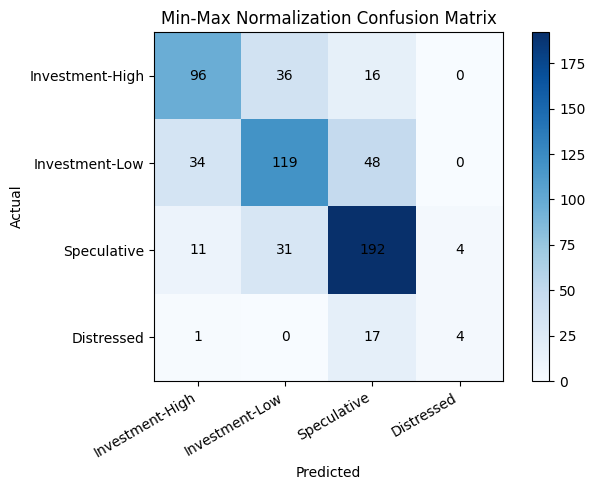

In [16]:
baseline_metrics = dict(metrics)

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

try:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

X_train_minmax, X_test_minmax, y_train_minmax, y_test_minmax = train_test_split(
    X.copy(),
    y_encoded.copy(),
    test_size=0.30,
    random_state=42,
    stratify=y_encoded,
)

numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler()),
    ]
)

categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", one_hot),
    ]
)

minmax_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipe, numeric_columns),
        ("categorical", categorical_pipe, categorical_columns),
    ],
    remainder="drop",
)

minmax_pipeline = Pipeline(
    steps=[
        ("preprocessor", minmax_preprocessor),
        ("model", XGBClassifier(random_state=42, eval_metric="mlogloss")),
    ]
)
minmax_pipeline.fit(X_train_minmax, y_train_minmax)

minmax_pred = minmax_pipeline.predict(X_test_minmax)
y_test_labels = label_encoder.inverse_transform(y_test_minmax)
y_pred_labels = label_encoder.inverse_transform(minmax_pred.astype(int))
minmax_metrics = evaluate_predictions(y_test_labels, y_pred_labels, CLASS_ORDER)

comparison_table = pd.DataFrame(
    [
        {
            "Scenario": "Baseline",
            "Accuracy": baseline_metrics["accuracy"],
            "Weighted F1": baseline_metrics["weighted_f1"],
            "Macro F1": baseline_metrics["macro_f1"],
        },
        {
            "Scenario": "Min-Max Normalization",
            "Accuracy": minmax_metrics["accuracy"],
            "Weighted F1": minmax_metrics["weighted_f1"],
            "Macro F1": minmax_metrics["macro_f1"],
        },
    ]
)

print(comparison_table.to_string(index=False))
print(minmax_metrics["classification_report_text"])

cm = np.array(minmax_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(7, 5))
image = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASS_ORDER)))
ax.set_yticks(range(len(CLASS_ORDER)))
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha="right")
ax.set_yticklabels(CLASS_ORDER)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Min-Max Normalization Confusion Matrix")

for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        ax.text(column_index, row_index, cm[row_index, column_index], ha="center", va="center", color="black")

fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()


## Experiment 7: Hyperparameter Tuning

This experiment uses the final selected preprocessing flow, fits `GridSearchCV` only on `X_train`, and evaluates the best estimator on the untouched `X_test`.

> **Note:** This is the authoritative tuning pass for the final model (distinct from the
> ablation study's Section 2, which uses `RandomizedSearchCV` over a wider search space
> purely to gauge HPO's isolated effect). Experiment 8 repeats this same `GridSearchCV`
> grid on Min-Max normalized features for comparison.


Best parameters:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}

Best cross-validation accuracy: 0.652817

Untuned vs tuned metrics:
Scenario  Accuracy  Weighted F1  Macro F1
 Untuned  0.666667     0.657103  0.570554
   Tuned  0.674877     0.663159  0.559655

Tuned classification report:
                 precision    recall  f1-score   support

Investment-High       0.65      0.66      0.65       148
 Investment-Low       0.65      0.55      0.60       201
    Speculative       0.70      0.84      0.76       238
     Distressed       0.60      0.14      0.22        22

       accuracy                           0.67       609
      macro avg       0.65      0.55      0.56       609
   weighted avg       0.67      0.67      0.66       609



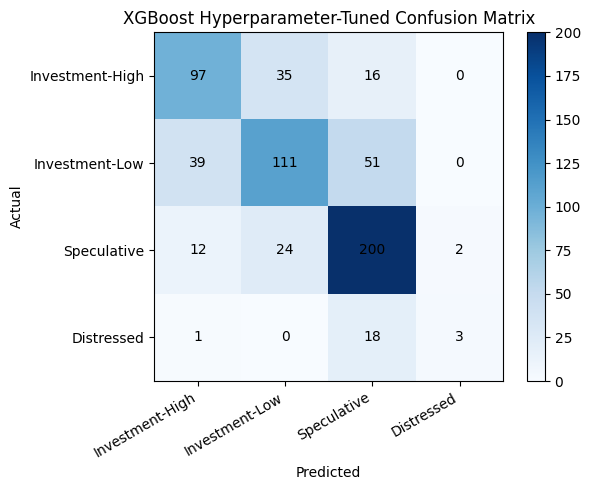

Conclusion: Keep - tuning improved or matched the untuned test performance.


In [17]:
# Experiment 7: Hyperparameter Tuning
from sklearn.base import clone
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

final_preprocessor = build_preprocessor(numeric_columns, categorical_columns)
base_model = clone(pipeline.named_steps["model"])

untuned_pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(numeric_columns, categorical_columns)),
        ("model", clone(base_model)),
    ]
)
untuned_pipeline.fit(X_train, y_train)
untuned_pred = untuned_pipeline.predict(X_test)
untuned_pred_labels = label_encoder.inverse_transform(untuned_pred.astype(int))
untuned_metrics = evaluate_predictions(y_test_labels, untuned_pred_labels, CLASS_ORDER)

search = GridSearchCV(
    estimator=Pipeline(
        steps=[
            ("preprocessor", build_preprocessor(numeric_columns, categorical_columns)),
            ("model", clone(base_model)),
        ]
    ),
    param_grid={
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
},
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="accuracy",
    n_jobs=-1,
    refit=True,
)
search.fit(X_train, y_train)

best_pipeline = search.best_estimator_
best_pred = best_pipeline.predict(X_test)
best_pred_labels = label_encoder.inverse_transform(best_pred.astype(int))
tuned_metrics = evaluate_predictions(y_test_labels, best_pred_labels, CLASS_ORDER)

print("Best parameters:")
print(search.best_params_)
print()
print(f"Best cross-validation accuracy: {search.best_score_:.6f}")
print()

comparison = pd.DataFrame(
    [
        {
            "Scenario": "Untuned",
            "Accuracy": untuned_metrics["accuracy"],
            "Weighted F1": untuned_metrics["weighted_f1"],
            "Macro F1": untuned_metrics["macro_f1"],
        },
        {
            "Scenario": "Tuned",
            "Accuracy": tuned_metrics["accuracy"],
            "Weighted F1": tuned_metrics["weighted_f1"],
            "Macro F1": tuned_metrics["macro_f1"],
        },
    ]
)
print("Untuned vs tuned metrics:")
print(comparison.to_string(index=False))
print()
print("Tuned classification report:")
print(tuned_metrics["classification_report_text"])

cm = np.array(tuned_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASS_ORDER)))
ax.set_yticks(range(len(CLASS_ORDER)))
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha="right")
ax.set_yticklabels(CLASS_ORDER)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("XGBoost Hyperparameter-Tuned Confusion Matrix")

for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        ax.text(column_index, row_index, cm[row_index, column_index], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

if tuned_metrics["accuracy"] > untuned_metrics["accuracy"] or (
    tuned_metrics["accuracy"] == untuned_metrics["accuracy"]
    and tuned_metrics["weighted_f1"] >= untuned_metrics["weighted_f1"]
):
    conclusion = "Keep"
    reason = "tuning improved or matched the untuned test performance."
else:
    conclusion = "Reject"
    reason = "tuning did not improve the untuned test performance."

print(f"Conclusion: {conclusion} - {reason}")


## Experiment 8: Min-Max Normalization + Hyperparameter Tuning

This experiment applies Min-Max normalization first, then runs `GridSearchCV` on the normalized training data only. The scaler and model are fit inside the cross-validation pipeline, so `X_test` stays untouched.

> **Note:** Comparing this experiment's test-set metrics against Experiment 7 to decide
> which preprocessing wins is a mild form of test-set reuse for model selection. Prefer
> comparing `best_score_` (CV accuracy) between the two when choosing a winner, and treat
> the `X_test` metrics as the final report only, not a selection criterion.


Best parameters:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}

Best cross-validation accuracy: 0.650000

Untuned vs tuned Min-Max metrics:
       Scenario  Accuracy  Weighted F1  Macro F1
Untuned Min-Max  0.674877     0.667183  0.573798
  Tuned Min-Max  0.678161     0.667834  0.580266

Tuned Min-Max classification report:
                 precision    recall  f1-score   support

Investment-High       0.66      0.67      0.66       148
 Investment-Low       0.64      0.55      0.59       201
    Speculative       0.71      0.84      0.77       238
     Distressed       0.80      0.18      0.30        22

       accuracy                           0.68       609
      macro avg       0.70      0.56      0.58       609
   weighted avg       0.68      0.68      0.67       609



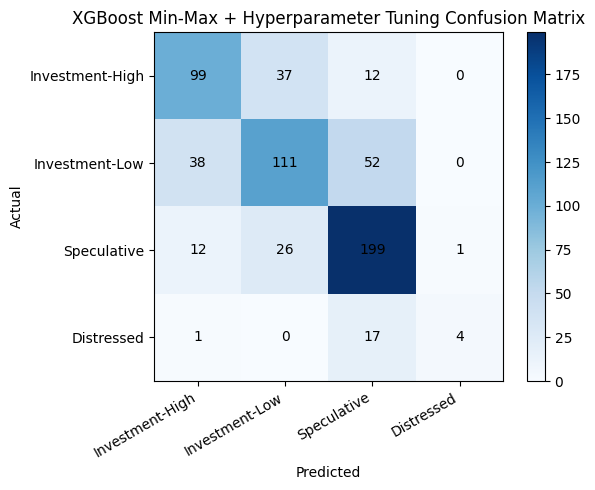

Conclusion: Keep - the tuned Min-Max pipeline improved or matched the untuned Min-Max test performance.


In [18]:
# Experiment 8: Min-Max Normalization + Hyperparameter Tuning
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

try:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

minmax_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", MinMaxScaler())]), numeric_columns),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", one_hot)]), categorical_columns),
    ]
)

base_model = clone(pipeline.named_steps["model"])

untuned_minmax_pipeline = Pipeline(
    steps=[
        ("preprocessor", minmax_preprocessor),
        ("model", clone(base_model)),
    ]
)
untuned_minmax_pipeline.fit(X_train, y_train)
untuned_minmax_pred = untuned_minmax_pipeline.predict(X_test)
untuned_minmax_pred_labels = label_encoder.inverse_transform(untuned_minmax_pred.astype(int))
untuned_minmax_metrics = evaluate_predictions(y_test_labels, untuned_minmax_pred_labels, CLASS_ORDER)

search = GridSearchCV(
    estimator=Pipeline(
        steps=[
            ("preprocessor", minmax_preprocessor),
            ("model", clone(base_model)),
        ]
    ),
    param_grid={
        "model__n_estimators": [100, 200],
        "model__max_depth": [3, 5],
        "model__learning_rate": [0.05, 0.1],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0],
    },
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="accuracy",
    n_jobs=-1,
    refit=True,
)
search.fit(X_train, y_train)

best_pipeline = search.best_estimator_
best_pred = best_pipeline.predict(X_test)
best_pred_labels = label_encoder.inverse_transform(best_pred.astype(int))
tuned_minmax_metrics = evaluate_predictions(y_test_labels, best_pred_labels, CLASS_ORDER)

print("Best parameters:")
print(search.best_params_)
print()
print(f"Best cross-validation accuracy: {search.best_score_:.6f}")
print()

comparison = pd.DataFrame(
    [
        {
            "Scenario": "Untuned Min-Max",
            "Accuracy": untuned_minmax_metrics["accuracy"],
            "Weighted F1": untuned_minmax_metrics["weighted_f1"],
            "Macro F1": untuned_minmax_metrics["macro_f1"],
        },
        {
            "Scenario": "Tuned Min-Max",
            "Accuracy": tuned_minmax_metrics["accuracy"],
            "Weighted F1": tuned_minmax_metrics["weighted_f1"],
            "Macro F1": tuned_minmax_metrics["macro_f1"],
        },
    ]
)
print("Untuned vs tuned Min-Max metrics:")
print(comparison.to_string(index=False))
print()
print("Tuned Min-Max classification report:")
print(tuned_minmax_metrics["classification_report_text"])

cm = np.array(tuned_minmax_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASS_ORDER)))
ax.set_yticks(range(len(CLASS_ORDER)))
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha="right")
ax.set_yticklabels(CLASS_ORDER)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("XGBoost Min-Max + Hyperparameter Tuning Confusion Matrix")

for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        ax.text(column_index, row_index, cm[row_index, column_index], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

if tuned_minmax_metrics["accuracy"] > untuned_minmax_metrics["accuracy"] or (
    tuned_minmax_metrics["accuracy"] == untuned_minmax_metrics["accuracy"]
    and tuned_minmax_metrics["weighted_f1"] >= untuned_minmax_metrics["weighted_f1"]
):
    conclusion = "Keep"
    reason = "the tuned Min-Max pipeline improved or matched the untuned Min-Max test performance."
else:
    conclusion = "Reject"
    reason = "the tuned Min-Max pipeline did not improve the untuned Min-Max test performance."

print(f"Conclusion: {conclusion} - {reason}")


## Explainable AI: SHAP Feature Importance

This section explains the final model trained using Min-Max normalization and hyperparameter tuning.


Final model used for SHAP:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

Top SHAP features:


,Feature,Mean Absolute SHAP Value,Rank
0,operatingCashFlowPerShare,0.380537,1
1,netProfitMargin,0.256559,2
2,debtRatio,0.251795,3
3,operatingCashFlowSalesRatio,0.236094,4
4,enterpriseValueMultiple,0.230030,5
5,payablesTurnover,0.207584,6
6,pretaxProfitMargin,0.207021,7
7,fixedAssetTurnover,0.193530,8
8,currentRatio,0.171539,9
9,returnOnCapitalEmployed,0.168163,10


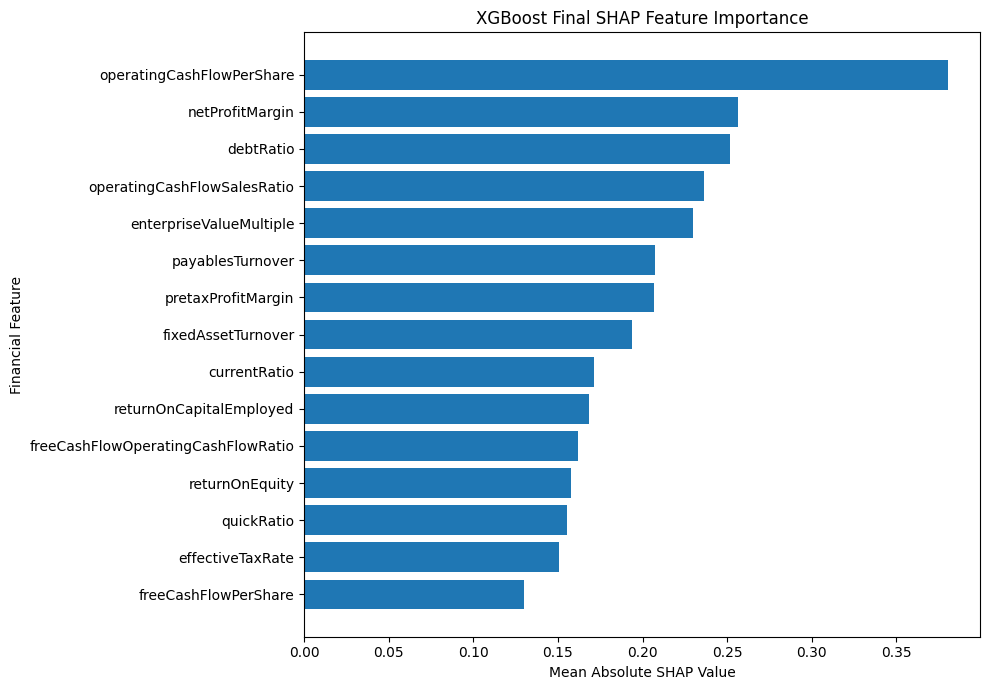

In [19]:
# Final SHAP Feature Importance
# This explains the final Min-Max normalized and hyperparameter-tuned model.

final_pipeline = best_pipeline

# Extract the fitted preprocessing component and fitted model.
final_preprocessor = final_pipeline.named_steps["preprocessor"]
final_model = final_pipeline.named_steps["model"]

# Apply the already-fitted preprocessing steps.
X_train_transformed = final_preprocessor.transform(X_train)
X_test_transformed = final_preprocessor.transform(X_test)

# Convert sparse matrices into normal NumPy arrays.
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Retrieve the transformed feature names.
feature_names = final_preprocessor.get_feature_names_out()

# Remove prefixes such as num__ and cat__ from the displayed names.
display_feature_names = np.array(
    [str(name).split("__", 1)[-1] for name in feature_names]
)

# Use a fixed sample size to reduce SHAP processing time.
background_size = min(100, X_train_transformed.shape[0])
explanation_size = min(100, X_test_transformed.shape[0])

background_data = X_train_transformed[:background_size]
explanation_data = X_test_transformed[:explanation_size]

# Select the correct SHAP explainer.
if final_model.__class__.__name__ == "LogisticRegression":
    shap_explainer = shap.LinearExplainer(
        final_model,
        background_data,
        feature_names=feature_names
    )
else:
    shap_explainer = shap.TreeExplainer(final_model)

# Calculate SHAP values.
shap_result = shap_explainer(explanation_data)

# Support different SHAP output formats.
if isinstance(shap_result, list):
    shap_array = np.stack(
        [np.asarray(class_values) for class_values in shap_result],
        axis=-1
    )
elif hasattr(shap_result, "values"):
    shap_array = np.asarray(shap_result.values)
else:
    shap_array = np.asarray(shap_result)

# Calculate mean absolute SHAP values.
if shap_array.ndim == 2:
    mean_abs_shap = np.mean(np.abs(shap_array), axis=0)

elif shap_array.ndim == 3:
    if shap_array.shape[1] == len(feature_names):
        # Shape: observations, features, classes
        mean_abs_shap = np.mean(np.abs(shap_array), axis=(0, 2))

    elif shap_array.shape[2] == len(feature_names):
        # Shape: classes, observations, features
        mean_abs_shap = np.mean(np.abs(shap_array), axis=(0, 1))

    else:
        raise ValueError(
            f"Unexpected SHAP shape: {shap_array.shape}"
        )
else:
    raise ValueError(
        f"Unsupported SHAP dimensions: {shap_array.ndim}"
    )

# Create the ranked feature importance table.
shap_importance = pd.DataFrame(
    {
        "Feature": display_feature_names,
        "Mean Absolute SHAP Value": mean_abs_shap
    }
)

shap_importance = shap_importance.sort_values(
    "Mean Absolute SHAP Value",
    ascending=False
).reset_index(drop=True)

shap_importance["Rank"] = shap_importance.index + 1
shap_importance["Mean Absolute SHAP Value"] = (
    shap_importance["Mean Absolute SHAP Value"].round(6)
)

print("Final model used for SHAP:")
print(final_model)

print("\nTop SHAP features:")
display(shap_importance.head(15))

# Set the model name for the chart.
model_title_names = {
    "DecisionTreeClassifier": "Decision Tree",
    "RandomForestClassifier": "Random Forest",
    "XGBClassifier": "XGBoost",
    "LogisticRegression": "Logistic Regression"
}

model_title = model_title_names.get(
    final_model.__class__.__name__,
    final_model.__class__.__name__
)

# Plot the 15 most influential features.
top_features = shap_importance.head(15).sort_values(
    "Mean Absolute SHAP Value",
    ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_features["Feature"],
    top_features["Mean Absolute SHAP Value"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Financial Feature")
plt.title(f"{model_title} Final SHAP Feature Importance")
plt.tight_layout()
plt.show()
